In [ ]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from matplotlib.colors import Normalize
from matplotlib.colors import TwoSlopeNorm
import scipy
from scipy.linalg import sqrtm
import scipy.linalg as la
import time
from tqdm.notebook import tqdm 


In [1]:
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
        
    #check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    #max_err = np.max(np.abs(check))

    #if max_err > check_tol:
    #    mag = np.abs(eigvals)
    #    print("Sorted |eigvals|:", np.sort(mag))
    #    raise RuntimeError(
    #        fr"Self-consistency violated: max |Δ| = {max_err}"
    #    )
    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,E,eta=1e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    return G_DD_r , A_DD ,Sigma_R ,Sigma_L 

def gamma_feilei(which, side, E):
    G_DD , A_DD , Sigma_R , Sigma_L = Gr_DD(
        H_q,H_l, H_r,
        T_12, T_LD, T_l, T_RD, T_r,
        N, E, eta=1e-6
    )

    Gamma_L = 1j * (Sigma_L - Sigma_L.conj().T)
    Gamma_R = 1j * (Sigma_R - Sigma_R.conj().T)

    if side == 'L':
        Gamma = Gamma_L
    elif side == 'R':
        Gamma = Gamma_R
    else:
        raise ValueError("side must be 'L' or 'R'")

    dim = Gamma.shape[0] // 2

    Gamma_ee = Gamma[:dim, :dim]
    Gamma_hh = Gamma[dim:, dim:]

    if which == 'e':
        return Gamma_ee
    elif which == 'h':
        return Gamma_hh
    else:
        raise ValueError("which must be 'e' or 'h'")

def G_feilei(which1, which2, side1, side2, E):

    G_DD , A_DD , Sigma_R , Sigma_L = Gr_DD(
        H_q, H_l, H_r,
        T_12, T_LD, T_l, T_RD, T_r,
        N, E, eta=1e-6
    )

    dim = 4  

    idx_L = np.arange(0, dim)
    idx_R = np.arange(dim*(N-1), dim*N)

    if side1 == 'L':
        idx_row = idx_L
    elif side1 == 'R':
        idx_row = idx_R
    else:
        raise ValueError("side1 must be L or R")

    if side2 == 'L':
        idx_col = idx_L
    elif side2 == 'R':
        idx_col = idx_R
    else:
        raise ValueError("side2 must be L or R")

    G_qp = G_DD[np.ix_(idx_row, idx_col)]

    subdim = dim // 2  # =2

    if which1 == 'e' and which2 == 'e':
        return G_qp[:subdim, :subdim]        # G^{ee}

    elif which1 == 'e' and which2 == 'h':
        return G_qp[:subdim, subdim:]    # G^{eh} G_qp[:subdim, subdim:]

    elif which1 == 'h' and which2 == 'e':
        return G_qp[subdim:, :subdim]         # G^{he} G_qp[subdim:, :subdim]

    elif which1 == 'h' and which2 == 'h':
        return G_qp[subdim:, subdim:]        # G^{hh}

    else:
        raise ValueError("which must be e or h")

def sanshejuzhen(which1, which2, side1, side2,E):

    Gamma_q = gamma_feilei(which1, side1,E)  # Γ_q^α
    Gamma_p = gamma_feilei(which2, side2,E)  # Γ_p^β

    G_qp = G_feilei(which1, which2, side1, side2,E)

    sqrt_Gamma_q = scipy.linalg.sqrtm(Gamma_q)
    sqrt_Gamma_p = scipy.linalg.sqrtm(Gamma_p)

    S = 1j * (sqrt_Gamma_q @ G_qp @ sqrt_Gamma_p)


    if side1 == side2 and which1 == which2:
        I_2 = np.eye(2) 
        S = S - I_2
    return S

def Green_lead_1(N, E, H, V, V_cm):
    """计算电极的自能 Sigma 和展宽 Gamma"""
    T = np.zeros((2*N, 2*N), dtype=complex)
    
    # MATLAB: T(1:N,1:N)=V\(E-H); T(1:N,N+1:2*N)=-V\V';
    # 使用 np.linalg.solve 替代 MATLAB 的左除 \
    T[0:N, 0:N] = np.linalg.solve(V, E - H)
    T[0:N, N:2*N] = -np.linalg.solve(V, V.conj().T)
    T[N:2*N, 0:N] = np.eye(N)
    
    eigenvalues, eigenvectors = np.linalg.eig(T)
    
    # 按特征值绝对值排序
    order = np.argsort(np.abs(eigenvalues))
    
    S1 = eigenvectors[0:N, order[0:N]]
    S2 = eigenvectors[N:2*N, order[0:N]]
    
    # 表面格林函数
    g11 = np.linalg.inv((E - H) - V @ S1 @ np.linalg.inv(S2))
    Sigma = V_cm @ g11 @ V_cm.conj().T
    Gamma = 1j * (Sigma - Sigma.conj().T)
    
    return Sigma, Gamma

def Green_device_1(N, M, E, H, V, Sigma_r, Sigma_l):
    """计算中心器件区的格林函数 (递归法)"""
    ALR = E - H
    
    # Gnn (从右向左递归)
    Gnn = np.zeros((M, N, N), dtype=complex)
    Gnn[M-1] = np.linalg.inv(ALR - Sigma_r)  # M-1 对应 MATLAB 的 M
    for n in range(M-2, 0, -1):              # 对应 MATLAB 的 M-1:-1:2
        Gnn[n] = np.linalg.inv(ALR - V @ Gnn[n+1] @ V.conj().T)
    Gnn[0] = np.linalg.inv(ALR - V @ Gnn[1] @ V.conj().T - Sigma_l)
    
    # G1n 
    G1n = Gnn[0].copy()
    for n in range(1, M):
        G1n = G1n @ V @ Gnn[n]
        
    # Gnn2 (从左向右递归)
    Gnn2 = np.zeros((M, N, N), dtype=complex)
    Gnn2[0] = np.linalg.inv(ALR - Sigma_l)
    for n in range(1, M-1):
        Gnn2[n] = np.linalg.inv(ALR - V.conj().T @ Gnn2[n-1] @ V)
    Gnn2[M-1] = np.linalg.inv(ALR - V.conj().T @ Gnn2[M-2] @ V - Sigma_r)
    
    # Gn1
    Gn1 = Gnn2[M-1].copy()
    for n in range(M-2, -1, -1):
        Gn1 = Gn1 @ V.conj().T @ Gnn2[n]
        
    return Gnn, G1n, Gnn2, Gn1




In [13]:
import numpy as np
import scipy.linalg as la

# ==========================================
# 1. 简化的参数与矩阵 (提取自你的系统)
# ==========================================
delta, a, t, UR, VL = 0.25e-3, 0.649, 38*0.25e-3, 200e-4/0.649, -0.1*38*0.25e-3
mu, hl = 4*delta, 8*delta

hhl = np.diag([-mu+2*t+VL, -mu+2*t+VL, mu-2*t-VL, mu-2*t-VL]) + np.diag([hl, -hl, -hl, hl])
vvt = np.diag([-t, -t, t, t])
vvs_L = np.zeros((4, 4), dtype=complex)  # 简化演示
V_L = vvt + vvs_L
V_cl = V_L.conj().T

H_l = hhl
T_l = V_L.conj().T
T_LD = V_cl  # 你的左耦合矩阵

# ==========================================
# 2. 你的方法
# ==========================================
def gr_L(T_l, A_l):
    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])
    eigvals, eigvecs = la.eig(Tmat)
    idx = np.argsort(np.abs(eigvals))
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
    lambdas, vecs = eigvals[:N], eigvecs[:, :N]
    S1, S2 = vecs[:N, :], vecs[N:, :]  
    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    # 你的核心逻辑： dagger 在前
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

# ==========================================
# 3. 老师的方法
# ==========================================
def Green_lead_1(N_dim, E_mat, H, V, V_cm):
    T = np.zeros((2*N_dim, 2*N_dim), dtype=complex)
    T[0:N_dim, 0:N_dim] = np.linalg.solve(V, E_mat - H)
    T[0:N_dim, N_dim:2*N_dim] = -np.linalg.solve(V, V.conj().T)
    T[N_dim:2*N_dim, 0:N_dim] = np.eye(N_dim)
    eigenvalues, eigenvectors = np.linalg.eig(T)
    order = np.argsort(np.abs(eigenvalues))
    S1 = eigenvectors[0:N_dim, order[0:N_dim]]
    S2 = eigenvectors[N_dim:2*N_dim, order[0:N_dim]]
    g11 = np.linalg.inv((E_mat - H) - V @ S1 @ np.linalg.inv(S2))
    # 老师的核心逻辑： dagger 在后
    return V_cm @ g11 @ V_cm.conj().T

# ==========================================
# 4. 对比计算
# ==========================================
E_mat = (0.0 + 1j * 1e-6) * np.eye(4, dtype=complex)

# 1. 用你的方法算自能
A_l = E_mat - H_l
gcl = gr_L(T_l, A_l)
Sigma_L_YOURS = zinengr_L(T_LD, gcl)

# 2. 用老师的方法算自能
# 【关键修复】：传入 T_LD.conj().T 才能抵消两人公式里的 dagger 顺序差异
Sigma_L_TEACHERS = Green_lead_1(4, E_mat, H_l, T_l, T_LD.conj().T)

# 3. 结果对比
err = np.max(np.abs(Sigma_L_YOURS - Sigma_L_TEACHERS))
print(f"验证完成，你的函数与老师函数的最大误差为: {err}")

验证完成，你的函数与老师函数的最大误差为: 1.9481757786848908e-20


In [23]:
import numpy as np
import scipy.linalg as la

# ==========================================
# 1. 简化的参数设置 (用小尺寸 M_sites 验证)
# ==========================================
delta = 0.25 * 1e-3
a = 6.49 * 0.1
t = 38 * delta
UR = 200 * 1e-4 / a
UR_L = 0
VL = -0.1 * t
mu = 4 * delta
hc = np.sqrt(mu**2 + delta**2)
h = 1.5 * hc
hl = 8 * delta
psi = 0
aL = 1
ac = 1
tL = t * aL
M_sites = 10  # 验证用的小层数

sigma_x = np.array([[0, 1], [1, 0]])
sigma_z = np.array([[1, 0], [0, -1]])

# --- 构造哈密顿量 ---
hh0 = np.zeros((4, 4), dtype=complex)
hh0[0,0] = -mu + 2*t; hh0[1,1] = -mu + 2*t
hh0[2,2] =  mu - 2*t; hh0[3,3] =  mu - 2*t

hhl = np.zeros((4, 4), dtype=complex)
hhl[0,0] = -mu + 2*tL + VL; hhl[1,1] = -mu + 2*tL + VL
hhl[2,2] =  mu - 2*tL - VL; hhl[3,3] =  mu - 2*tL - VL

hhd = np.zeros((4, 4), dtype=complex)
hhd[0,3] = delta; hhd[3,0] = delta
hhd[1,2] = -delta; hhd[2,1] = -delta

vvt = np.zeros((4, 4), dtype=complex)
vvt[0,0] = -t; vvt[1,1] = -t
vvt[2,2] =  t; vvt[3,3] =  t

vvs = np.zeros((4, 4), dtype=complex)
vvs[0,0] = -1j*UR; vvs[1,1] = 1j*UR
vvs[2,2] = -1j*UR; vvs[3,3] = 1j*UR

vvs_L = np.zeros((4, 4), dtype=complex)
vvs_L[0,0] = -1j*UR_L; vvs_L[1,1] = 1j*UR_L
vvs_L[2,2] = -1j*UR_L; vvs_L[3,3] = 1j*UR_L

V = vvt + vvs
V_L = aL * vvt + vvs_L
V_cr = ac * vvt + vvs_L
V_cl = V_cr.conj().T

hhyc = np.zeros((4, 4), dtype=complex)
hhyc[0,1] = -1j*h; hhyc[1,0] = 1j*h
hhyc[2,3] = -1j*h; hhyc[3,2] = 1j*h

hhzl = np.zeros((4, 4), dtype=complex)
hhzl[0,0] = hl; hhzl[1,1] = -hl
hhzl[2,2] = -hl; hhzl[3,3] = hl

sigma_term = hl * np.cos(psi) * sigma_x + hl * np.sin(psi) * sigma_z
hhzr = np.block([
    [sigma_term, np.zeros((2, 2))],
    [np.zeros((2, 2)), -sigma_term]
])

# 输入矩阵
H_q = hh0 + hhyc + hhd
T_12 = V
H_l = hhl + hhzl
T_l = V_L.conj().T
H_r = hhl + hhzr
T_r = V_L
T_LD = V_cl
T_RD = V_cr

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

# ==========================================
# 2. 两个引擎定义
# ==========================================
def Green_lead_1(N_dim, E_mat, H, V, V_cm):
    T = np.zeros((2*N_dim, 2*N_dim), dtype=complex)
    T[0:N_dim, 0:N_dim] = np.linalg.solve(V, E_mat - H)
    T[0:N_dim, N_dim:2*N_dim] = -np.linalg.solve(V, V.conj().T)
    T[N_dim:2*N_dim, 0:N_dim] = np.eye(N_dim)
    eigenvalues, eigenvectors = np.linalg.eig(T)
    order = np.argsort(np.abs(eigenvalues))
    S1 = eigenvectors[0:N_dim, order[0:N_dim]]
    S2 = eigenvectors[N_dim:2*N_dim, order[0:N_dim]]
    g11 = np.linalg.inv((E_mat - H) - V @ S1 @ np.linalg.inv(S2))
    return V_cm @ g11 @ V_cm.conj().T

def Green_device_1(N, M, E_mat, H, V, Sigma_r, Sigma_l):
    ALR = E_mat - H
    Gnn = np.zeros((M, N, N), dtype=complex)
    Gnn[M-1] = np.linalg.inv(ALR - Sigma_r)
    for n in range(M-2, -1, -1):
        if n == 0:
            Gnn[0] = np.linalg.inv(ALR - V @ Gnn[1] @ V.conj().T - Sigma_l)
        else:
            Gnn[n] = np.linalg.inv(ALR - V @ Gnn[n+1] @ V.conj().T)
            
    G1n = Gnn[0].copy()
    for n in range(1, M):
        G1n = G1n @ V @ Gnn[n]
        
    Gnn2 = np.zeros((M, N, N), dtype=complex)
    Gnn2[0] = np.linalg.inv(ALR - Sigma_l)
    for n in range(1, M):
        if n == M-1:
            Gnn2[M-1] = np.linalg.inv(ALR - V.conj().T @ Gnn2[M-2] @ V - Sigma_r)
        else:
            Gnn2[n] = np.linalg.inv(ALR - V.conj().T @ Gnn2[n-1] @ V)
            
    Gn1 = Gnn2[M-1].copy()
    for n in range(M-2, -1, -1):
        Gn1 = Gn1 @ V.conj().T @ Gnn2[n]
        
    return Gnn, G1n, Gnn2, Gn1

def Gr_DD_direct(H_q, T_12, Sigma_R, Sigma_L, M, E_mat):
    d = H_q.shape[0]
    A_DD = np.zeros((M*d, M*d), dtype=complex)
    for i in range(M):
        if i == 0:
            A_DD[i*d:(i+1)*d, i*d:(i+1)*d] = E_mat - H_q - Sigma_L
        elif i == M-1:
            A_DD[i*d:(i+1)*d, i*d:(i+1)*d] = E_mat - H_q - Sigma_R
        else:
            A_DD[i*d:(i+1)*d, i*d:(i+1)*d] = E_mat - H_q
        
        if i < M-1:
            A_DD[i*d:(i+1)*d, (i+1)*d:(i+2)*d] = -T_12
        if i > 0:
            A_DD[i*d:(i+1)*d, (i-1)*d:i*d] = -T_12.conj().T
    # 核心：直接把巨大的 A_DD 求逆
    return np.linalg.inv(A_DD)

# ==========================================
# 3. 对比与打印输出
# ==========================================
E_val = 0.0
eta = 1e-6
E_mat = (E_val + 1j * eta) * np.eye(4, dtype=complex)

# 获取两个电极自能
Sigma_L = Green_lead_1(4, E_mat, H_l, T_l, T_LD.conj().T)
Sigma_R = Green_lead_1(4, E_mat, H_r, T_r, T_RD.conj().T)

# 1. 递归法提取 4 个角落
Gnn, G1n, Gnn2, Gn1 = Green_device_1(4, M_sites, E_mat, H_q, T_12, Sigma_R, Sigma_L)

# 2. 暴力法算整个巨大的格林函数矩阵
G_DD_r = Gr_DD_direct(H_q, T_12, Sigma_R, Sigma_L, M_sites, E_mat)

# 3. 切片比对误差
d = 4
M = M_sites
err_Gnn0  = np.max(np.abs(Gnn[0]  - G_DD_r[0:d, 0:d]))
err_Gnn2M = np.max(np.abs(Gnn2[M-1] - G_DD_r[(M-1)*d:M*d, (M-1)*d:M*d]))
err_G1n   = np.max(np.abs(G1n   - G_DD_r[0:d, (M-1)*d:M*d]))
err_Gn1   = np.max(np.abs(Gn1   - G_DD_r[(M-1)*d:M*d, 0:d]))

print("-" * 50)
print(f"验证 Gnn[0]   (左上角) 误差: {err_Gnn0:.5e}")
print(f"验证 Gnn2[M-1](右下角) 误差: {err_Gnn2M:.5e}")
print(f"验证 G1n      (右上角) 误差: {err_G1n:.5e}")
print(f"验证 Gn1      (左下角) 误差: {err_Gn1:.5e}")
print("-" * 50)

--------------------------------------------------
验证 Gnn[0]   (左上角) 误差: 1.78522e-14
验证 Gnn2[M-1](右下角) 误差: 1.69977e-14
验证 G1n      (右上角) 误差: 2.56190e-14
验证 Gn1      (左下角) 误差: 2.86429e-14
--------------------------------------------------


Calculating Energy Points:   0%|          | 0/101 [00:00<?, ?it/s]

Elapsed time: 0.03 seconds


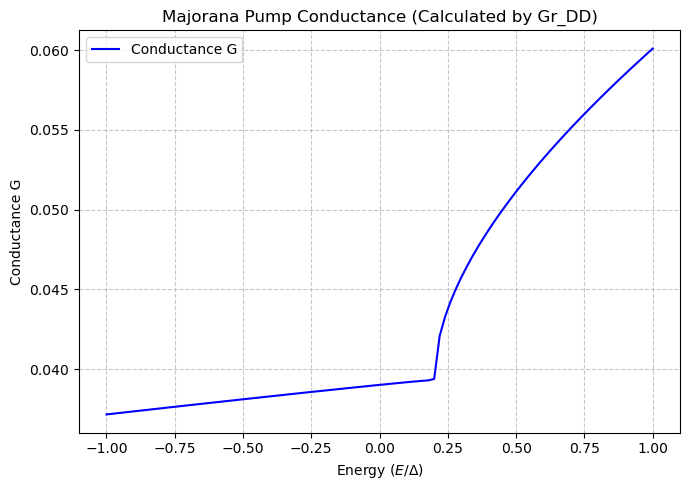

In [21]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import time
from tqdm.notebook import tqdm

# =========================================================================
# 1. 泡利矩阵与物理参数设置
# =========================================================================
s0 = np.array([[1, 0], [0, 1]], dtype=complex)
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)

# 基础参数
delta = 0.25 * 1e-3
a = 6.49 * 0.1
scale = 1
t = 38 * delta
UR = 200 * 1e-4 / a
UR_L = 0
VL = -0.1 * t
mu = 4 * delta
hc = np.sqrt(mu**2 + delta**2)
h = 1.5 * hc
hl = 8 * delta
psi = 0
aL = 1
ac = 1
tL = t * aL

# --- 【关键变量】中心器件的层数 ---
# 必须定义为整数，原代码中 N=4 是自由度，M 是层数。
# 这里为了与你的 Gr_DD 函数(它的层数变量名为 N)对接，我们统一叫 N_sites
N_sites = 2
# 如果你测试时觉得算得太慢，可以临时把上面这行注释掉，用下面这行：
# N_sites = 2 

# =========================================================================
# 2. 哈密顿量与跳跃矩阵构造
# =========================================================================
# (1) 基础 Onsite 矩阵
hh0 = np.zeros((4, 4), dtype=complex)
hh0[0,0] = -mu + 2*t; hh0[1,1] = -mu + 2*t
hh0[2,2] =  mu - 2*t; hh0[3,3] =  mu - 2*t

hhl = np.zeros((4, 4), dtype=complex)
hhl[0,0] = -mu + 2*tL + VL; hhl[1,1] = -mu + 2*tL + VL
hhl[2,2] =  mu - 2*tL - VL; hhl[3,3] =  mu - 2*tL - VL

hhd = np.zeros((4, 4), dtype=complex)
hhd[0,3] = delta; hhd[3,0] = delta
hhd[1,2] = -delta; hhd[2,1] = -delta

# (2) 跳跃矩阵 (Hopping)
vvt = np.zeros((4, 4), dtype=complex)
vvt[0,0] = -t; vvt[1,1] = -t
vvt[2,2] =  t; vvt[3,3] =  t

vvs = np.zeros((4, 4), dtype=complex)
vvs[0,0] = -1j*UR; vvs[1,1] = 1j*UR
vvs[2,2] = -1j*UR; vvs[3,3] = 1j*UR

vvs_L = np.zeros((4, 4), dtype=complex)
vvs_L[0,0] = -1j*UR_L; vvs_L[1,1] = 1j*UR_L
vvs_L[2,2] = -1j*UR_L; vvs_L[3,3] = 1j*UR_L

V = vvt + vvs
V_L = aL * vvt + vvs_L
V_cr = ac * vvt + vvs_L
V_cl = V_cr.conj().T

V_r = V_L
V_l = V_L.conj().T

# (3) 塞曼项矩阵 (Zeeman)
hhyc = np.zeros((4, 4), dtype=complex)
hhyc[0,1] = -1j*h; hhyc[1,0] = 1j*h
hhyc[2,3] = -1j*h; hhyc[3,2] = 1j*h

hhzl = np.zeros((4, 4), dtype=complex)
hhzl[0,0] = hl; hhzl[1,1] = -hl
hhzl[2,2] = -hl; hhzl[3,3] = hl

sigma_term = hl * np.cos(psi) * sigma_x + hl * np.sin(psi) * sigma_z
hhzr = np.block([
    [sigma_term, np.zeros((2, 2))],
    [np.zeros((2, 2)), -sigma_term]
])

# (4) 组装最终输入给 Gr_DD 的矩阵
H_q = hh0 + hhyc + hhd
T_12 = V
H_l = hhl + hhzl
T_l = V_l
H_r = hhl + hhzr
T_r = V_r
T_LD = V_cl
T_RD = V_cr

# =========================================================================
# 3. 你的底层格林函数求解器 (保持原样)
# =========================================================================
def gr_L(T_l_mat, A_l_mat, check_tol=1e-6):
    N_dim = T_l_mat.shape[0]
    I_mat = np.eye(N_dim)
    Tmat = np.block([
        [np.linalg.inv(T_l_mat) @ A_l_mat, -np.linalg.inv(T_l_mat) @ T_l_mat.conj().T],
        [I_mat, np.zeros((N_dim, N_dim))]
    ])

    # 使用 scipy.linalg.eig 替代你未导入的 eig
    eigvals, eigvecs = la.eig(Tmat)

    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    S1 = eigvecs[:N_dim, :N_dim] 
    S2 = eigvecs[N_dim:, :N_dim]  

    gL = np.linalg.inv(A_l_mat - T_l_mat @ S1 @ np.linalg.inv(S2))
    return gL

def zinengr_L(T_LD_wei, gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_mat, H_l_mat, H_r_mat, T_12_mat, T_LD_mat, T_l_mat, T_RD_mat, T_r_mat, num_sites, E_val, eta=1e-6):
    d_dim = H_q_mat.shape[0]
    Z = np.zeros((d_dim, d_dim), dtype=complex)

    EI_gai = np.block([
        [(E_val + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E_val + 1j*eta)*s0]
    ])

    # 左右电极自能
    A_l_mat = EI_gai - H_l_mat
    gcl = gr_L(T_l_mat, A_l_mat)
    Sigma_L = zinengr_L(T_LD_mat, gcl)

    A_r_mat = EI_gai - H_r_mat
    gcr = gr_L(T_r_mat, A_r_mat)
    Sigma_R = zinengr_L(T_RD_mat, gcr)

    # 构造大矩阵 A_DD
    A_DD = [[Z.copy() for _ in range(num_sites)] for _ in range(num_sites)]

    for i in range(num_sites):
        if i == 0:
            A_DD[i][i] = EI_gai - H_q_mat - Sigma_L
        elif i == num_sites-1:
            A_DD[i][i] = EI_gai - H_q_mat - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q_mat

        if i < num_sites-1:
            A_DD[i][i+1] = -T_12_mat

        if i > 0:
            A_DD[i][i-1] = -T_12_mat.conj().T
            
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r, A_DD, Sigma_R, Sigma_L 

# =========================================================================
# 4. 主循环：计算能量网格上的透射率与电导
# =========================================================================
eta = 1e-8
Mdata = 101  # 测试时建议用 101 个点，跑通了再调到 301
Energy = np.linspace(-1, 1, Mdata)
G = np.zeros(Mdata, dtype=float)

start_time = time.time()
d = 4  # 每个格点的局部自由度矩阵维度

for n in tqdm(range(Mdata), desc="Calculating Energy Points"):
    ep = Energy[n] * delta
    
    # --- 1. 调用你自己的全空间格林函数求解器 Gr_DD ---
    # 注意这里传入的层数是 N_sites
    G_DD_r, A_DD, Sigma_R, Sigma_L = Gr_DD(
        H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N_sites, ep, eta=eta
    )
    
    # --- 2. 计算电极展宽函数 Gamma ---
    Gamma_L = 1j * (Sigma_L - Sigma_L.conj().T)
    Gamma_R = 1j * (Sigma_R - Sigma_R.conj().T)
    
    # --- 3. 提取 Gamma 的电子与空穴块 ---
    Gamma_ee_l = Gamma_L[0:2, 0:2]
    Gamma_ee_r = Gamma_R[0:2, 0:2]
    Gamma_hh_r = Gamma_R[2:4, 2:4]  # 透射率计算只需要用右侧的空穴块
    
    # --- 4. 核心步骤：从大矩阵 G_DD_r 中精准切片提取角落小块 ---
    # G1n: 右上角 (从右端 N_sites 传输到左端 1)
    G1n = G_DD_r[0:d, (N_sites-1)*d : N_sites*d]
    
    # GNN: 右下角 (右端 N_sites 处的局域格林函数)
    GNN = G_DD_r[(N_sites-1)*d : N_sites*d, (N_sites-1)*d : N_sites*d]
    
    # --- 5. 提取格林函数的 ee 和 eh 子块 ---
    G1n_ee = G1n[0:2, 0:2]
    G1n_eh = G1n[0:2, 2:4]
    GNN_eh = GNN[0:2, 2:4]
    
    # --- 6. 使用 Fisher-Lee 公式计算透射率 ---
    Tee = np.real(np.trace(Gamma_ee_l @ G1n_ee @ Gamma_ee_r @ G1n_ee.conj().T))
    T_CAR = np.real(np.trace(Gamma_ee_l @ G1n_eh @ Gamma_hh_r @ G1n_eh.conj().T))
    T_LAR = np.real(np.trace(Gamma_ee_r @ GNN_eh @ Gamma_hh_r @ GNN_eh.conj().T))
    
    # --- 7. 最终电导计算 ---
    G[n] = (Tee + T_CAR + 2 * T_LAR) / 2

print(f"Elapsed time: {time.time() - start_time:.2f} seconds")

# =========================================================================
# 5. 绘图展示
# =========================================================================
plt.figure(figsize=(7, 5))
plt.plot(Energy, G, 'b-', linewidth=1.5, label='Conductance G')
plt.xlabel(r'Energy ($E/\Delta$)')
plt.ylabel('Conductance G')
plt.title('Majorana Pump Conductance (Calculated by Gr_DD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
#右边
t_R=25
mu_R=0

Vz=2
varphi_s = np.pi*0  #z_x平面

delta=1
chaodaojiao=0

alpha_R=2
a=1

#左边
t_L=30
mu_L=0

#耦合
t_c=15

T_Tc=0.5
Delta = delta * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))
KBT=2 * delta * T_Tc / 3.5
shumu=int(np.floor(50*delta/(2*np.pi*KBT)))*1

N=2

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(t,u, m_zx,Bjiao, weizhi,chaodaojiao):
    if weizhi==1:
        Delta_X= np.zeros((2,2))
        HX_block=-(u-2*t)*s0 
    elif weizhi==2:
        Delta_X= Delta * np.exp(1j*chaodaojiao) * 1j * sy
        HX_block=-(u-2*t)*s0 + m_zx*np.cos(Bjiao)*sz+ m_zx*np.sin(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(t,alpha_R):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*alpha_R*sy/(2*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(t_L,mu_L, 0,0, 1,0)
H_L_right_to_left_hop=H_hop(t_L,0)

#中间矩阵信息
H_center_to_L=H_hop(t_L,0)

H_center =H_onsite(t_L,mu_L, 0,0, 1,0)
H_center_right_to_left_hop=H_hop(t_L,0)

H_R_to_center=H_hop(t_c,0)

#右边矩阵信息
H_R_onsite=H_onsite(t_R,mu_R, Vz,varphi_s, 2,chaodaojiao)
H_R_right_to_left_hop=H_hop(t_R, alpha_R)

#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop.conj().T

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center

#print(H_R_to_center)

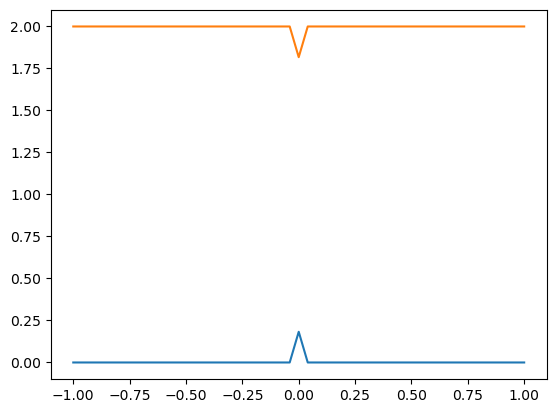

In [14]:
E_set=np.linspace(-1,1,51)
G_E_set=[]
Ree_set=[]
for E in E_set:
    S_he_LL= sanshejuzhen('h', 'e', 'L', 'L',E)
    Rhe=np.trace(S_he_LL.conj().T @ S_he_LL).real
    S_ee_LL= sanshejuzhen('e', 'e', 'L', 'L',E)
    Ree=np.trace(S_ee_LL.conj().T @ S_ee_LL).real
    Ree_set.append(Ree)
    G_E=(2-Ree+Rhe)
    G_E_set.append(G_E)
plt.plot(E_set,G_E_set)
plt.plot(E_set,Ree_set)

In [32]:
#参数1
dela = 0.25
chaodaojiao = 0
a=0.648
t =9.5
af =40



#两边
mz=2 #0.95
U=-0.95
#(my = 0.954776)

#中间
h=2*dela 
zhongjian_saimanjiao=np.pi*0

mu = 0.5*(h**2-dela**2)

#T_Tc=1e-3
Delta = dela#* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

N=2
q=0


#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(mx,mz,Bjiao,weizhi,chaodaojiao):
    if weizhi==1:
        Delta_X= np.zeros((2,2))
        HX_block=(U-(mu-2*t))*s0 + mz*sz 
    elif weizhi==2:
        Delta_X=Delta * np.exp(1j*chaodaojiao) * 1j * sy
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy +mx*np.cos(Bjiao)*sx
    elif weizhi==3:
        Delta_X=  np.zeros((2,2))
        HX_block=(U-(mu-2*t))*s0 + mz*sz 
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af,t):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(1*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(0,mz,0,1,chaodaojiao)
H_L_right_to_left_hop=H_hop(0,t)

#中间矩阵信息
H_center_to_L=H_hop(0,t)

H_center=H_onsite(h,0,zhongjian_saimanjiao,2,chaodaojiao)
H_center_right_to_left_hop=H_hop(af,t)

H_R_to_center=H_hop(0,t)

#右边矩阵信息
H_R_onsite=H_onsite(0,mz,0,3,chaodaojiao)
H_R_right_to_left_hop=H_hop(0,t)


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop.conj().T

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center


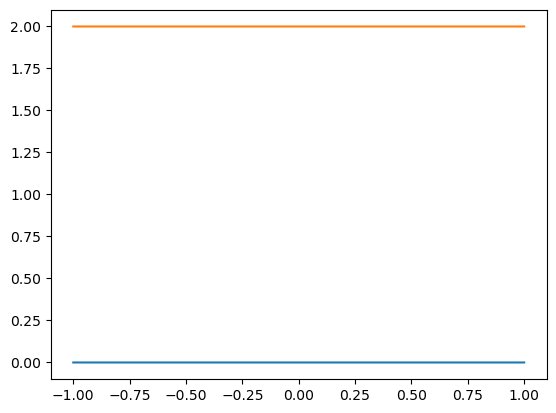

In [11]:
E_set=np.linspace(-1,1,3)
G_E_set=[]
Ree_set=[]
for E in E_set:
    S_he_LL= sanshejuzhen('h', 'e', 'L', 'L',E)
    Rhe=np.trace(S_he_LL.conj().T @ S_he_LL).real
    S_ee_LL= sanshejuzhen('e', 'e', 'L', 'L',E)
    Ree=np.trace(S_ee_LL.conj().T @ S_ee_LL).real
    Ree_set.append(Ree)
    G_E=(2-Ree+Rhe)
    G_E_set.append(G_E)
plt.plot(E_set,G_E_set)
plt.plot(E_set,Ree_set)

In [ ]:
def Scatter_NSN(NA, M, Gamma_l, Gamma_r, G1n, Gnn, Gn1, Gnn2):
    """计算散射矩阵 S (对应原代码 Scatter_NSN，当前主循环中被注释)"""
    N_dim = 2 * NA
    sq_Gamma_l = la.sqrtm(Gamma_l)
    sq_Gamma_r = la.sqrtm(Gamma_r)
    
    S_11 = -np.eye(N_dim) + 1j * sq_Gamma_l @ Gnn[0] @ sq_Gamma_l
    S_12 = 1j * sq_Gamma_l @ G1n @ sq_Gamma_r
    S_21 = 1j * sq_Gamma_r @ Gn1 @ sq_Gamma_l
    S_22 = -np.eye(N_dim) + 1j * sq_Gamma_r @ Gnn2[M-1] @ sq_Gamma_r
    
    S = np.block([
        [S_11, S_12],
        [S_21, S_22]
    ])
    return S

Calculating Energy Points:   0%|          | 0/301 [00:00<?, ?it/s]

Elapsed time: 19.86 seconds


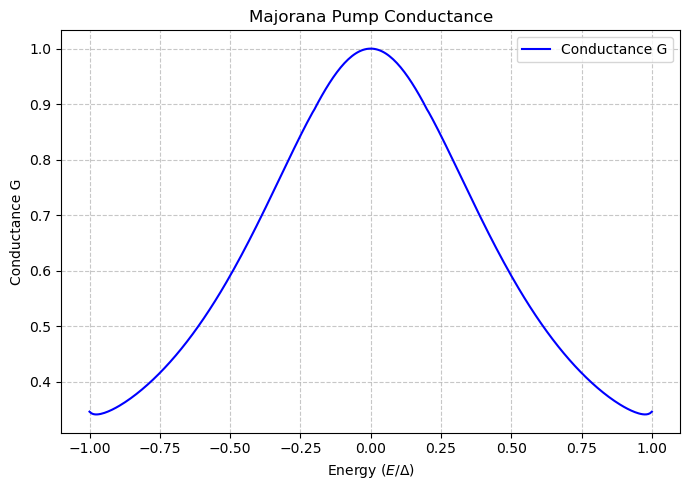

In [12]:
# 计时开始
start_time = time.time()

# --- 参数设置 (Parameter Setting) ---
NA = 2
N = 4 
delta = 0.25 * 1e-3
a = 6.49 * 0.1
scale = 1
t = 38 * delta
UR = 200 * 1e-4 / a
UR_L = 0
VL = -0.1 * t
mu = 4 * delta
hc = np.sqrt(mu**2 + delta**2)
h = 1.5 * hc
omega = 2 * np.pi
T_period = 2 * np.pi / omega
tt = 0
hl = 8 * delta
M = int(np.floor(2 * 10**3 * scale / a))
psi = 0
ee = 0
M_l = 20
aL = 1
ac = 1
tL = t * aL
alpha_L = 2 * UR_L

sigma_x = np.array([[0, 1], [1, 0]])
sigma_z = np.array([[1, 0], [0, -1]])

eta = 1e-8
Mdata = 301
Energy = np.linspace(-1, 1, Mdata)
G = np.zeros(Mdata, dtype=float)

# --- 构造独立于能量 E 的哈密顿量分块矩阵 ---
hh0 = np.zeros((4, 4), dtype=complex)
hh0[0,0] = -mu + 2*t; hh0[1,1] = -mu + 2*t
hh0[2,2] =  mu - 2*t; hh0[3,3] =  mu - 2*t

hhl = np.zeros((4, 4), dtype=complex)
hhl[0,0] = -mu + 2*tL + VL; hhl[1,1] = -mu + 2*tL + VL
hhl[2,2] =  mu - 2*tL - VL; hhl[3,3] =  mu - 2*tL - VL

hhd = np.zeros((4, 4), dtype=complex)
hhd[0,3] = delta; hhd[3,0] = delta
hhd[1,2] = -delta; hhd[2,1] = -delta

vvt = np.zeros((4, 4), dtype=complex)
vvt[0,0] = -t; vvt[1,1] = -t
vvt[2,2] =  t; vvt[3,3] =  t

vvs = np.zeros((4, 4), dtype=complex)
vvs[0,0] = -1j*UR; vvs[1,1] = 1j*UR
vvs[2,2] = -1j*UR; vvs[3,3] = 1j*UR

vvs_L = np.zeros((4, 4), dtype=complex)
vvs_L[0,0] = -1j*UR_L; vvs_L[1,1] = 1j*UR_L
vvs_L[2,2] = -1j*UR_L; vvs_L[3,3] = 1j*UR_L

V = vvt + vvs
V_L = aL * vvt + vvs_L
V_cr = ac * vvt + vvs_L
V_cl = V_cr.conj().T

V_r = V_L
V_l = V_L.conj().T

hx = 0
hhyc = np.zeros((4, 4), dtype=complex)
hhyc[0,1] = -1j*h; hhyc[1,0] = 1j*h
hhyc[2,3] = -1j*h; hhyc[3,2] = 1j*h

hhzc = np.zeros((4, 4), dtype=complex)

hhzl = np.zeros((4, 4), dtype=complex)
hhzl[0,0] = hl; hhzl[1,1] = -hl
hhzl[2,2] = -hl; hhzl[3,3] = hl

# 右电极塞曼项
sigma_term = hl * np.cos(psi) * sigma_x + hl * np.sin(psi) * sigma_z
hhzr = np.block([
    [sigma_term, np.zeros((2, 2))],
    [np.zeros((2, 2)), -sigma_term]
])

H = hh0 + hhzc + hhyc + hhd
H_l = hhl + hhzl
H_r = hhl + hhzr

# ==========================================
# 3. 能量循环计算 (替代 MATLAB 的 parfor)
# ==========================================

# tqdm 将在 Jupyter 中显示进度条
for n in tqdm(range(Mdata), desc="Calculating Energy Points"):
    ep = Energy[n] * delta
    E_mat = (ep + 1j * eta) * np.eye(4, dtype=complex)
    
    # 计算电极格林函数
    Sigma_r, Gamma_r = Green_lead_1(N, E_mat, H_r, V_r, V_cr)
    Sigma_l, Gamma_l = Green_lead_1(N, E_mat, H_l, V_l, V_cl)
    
    # 提取电子与空穴块
    Gamma_ee_l = Gamma_l[0:2, 0:2]
    Gamma_ee_r = Gamma_r[0:2, 0:2]
    Gamma_hh_l = Gamma_l[2:4, 2:4]
    Gamma_hh_r = Gamma_r[2:4, 2:4]
    
    # 器件格林函数
    Gnn, G1n, Gnn2, Gn1 = Green_device_1(N, M, E_mat, H, V, Sigma_r, Sigma_l)
    
    # 提取末端格林函数
    GNN = Gnn2[M-1]
    G1n_ee = G1n[0:2, 0:2]
    G1n_eh = G1n[0:2, 2:4]
    GNN_eh = GNN[0:2, 2:4]
    
    # 计算各个过程的透射率
    Tee = np.real(np.trace(Gamma_ee_l @ G1n_ee @ Gamma_ee_r @ G1n_ee.conj().T))
    T_CAR = np.real(np.trace(Gamma_ee_l @ G1n_eh @ Gamma_hh_r @ G1n_eh.conj().T))
    T_LAR = np.real(np.trace(Gamma_ee_r @ GNN_eh @ Gamma_hh_r @ GNN_eh.conj().T))
    
    # 最终电导计算
    G[n] = (Tee + T_CAR + 2 * T_LAR) / 2

# 输出耗时
print(f"Elapsed time: {time.time() - start_time:.2f} seconds")

# ==========================================
# 4. 绘图展示
# ==========================================
plt.figure(figsize=(7, 5))
plt.plot(Energy, G, 'b-', linewidth=1.5, label='Conductance G')
plt.xlabel(r'Energy ($E/\Delta$)')
plt.ylabel('Conductance G')
plt.title('Majorana Pump Conductance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Calculating Energy Points:   0%|          | 0/301 [00:00<?, ?it/s]

Elapsed time: 0.07 seconds


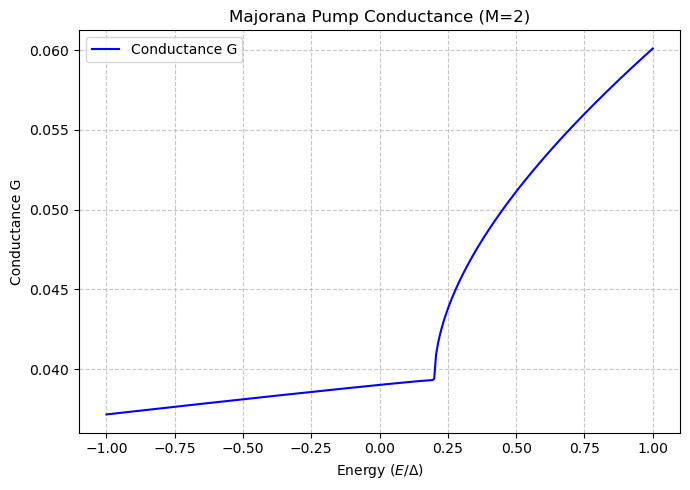

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
import time
from tqdm.notebook import tqdm  # 如果在普通终端运行，请改成 from tqdm import tqdm

# 计时开始
start_time = time.time()

# --- 参数设置 (Parameter Setting) ---
NA = 2
N = 4 
delta = 0.25 * 1e-3
a = 6.49 * 0.1
scale = 1
t = 38 * delta
UR = 200 * 1e-4 / a
UR_L = 0
VL = -0.1 * t
mu = 4 * delta
hc = np.sqrt(mu**2 + delta**2)
h = 1.5 * hc
omega = 2 * np.pi
T_period = 2 * np.pi / omega
tt = 0
hl = 8 * delta

# ================= 关键修改 =================
# M = int(np.floor(2 * 10**3 * scale / a))  # 原来的 3081 个点
M = 2  # 现在的 2 个点
# ==========================================

psi = 0
ee = 0
M_l = 20
aL = 1
ac = 1
tL = t * aL
alpha_L = 2 * UR_L

sigma_x = np.array([[0, 1], [1, 0]])
sigma_z = np.array([[1, 0], [0, -1]])

eta = 1e-8
Mdata = 301
Energy = np.linspace(-1, 1, Mdata)
G = np.zeros(Mdata, dtype=float)

# --- 构造独立于能量 E 的哈密顿量分块矩阵 ---
hh0 = np.zeros((4, 4), dtype=complex)
hh0[0,0] = -mu + 2*t; hh0[1,1] = -mu + 2*t
hh0[2,2] =  mu - 2*t; hh0[3,3] =  mu - 2*t

hhl = np.zeros((4, 4), dtype=complex)
hhl[0,0] = -mu + 2*tL + VL; hhl[1,1] = -mu + 2*tL + VL
hhl[2,2] =  mu - 2*tL - VL; hhl[3,3] =  mu - 2*tL - VL

hhd = np.zeros((4, 4), dtype=complex)
hhd[0,3] = delta; hhd[3,0] = delta
hhd[1,2] = -delta; hhd[2,1] = -delta

vvt = np.zeros((4, 4), dtype=complex)
vvt[0,0] = -t; vvt[1,1] = -t
vvt[2,2] =  t; vvt[3,3] =  t

vvs = np.zeros((4, 4), dtype=complex)
vvs[0,0] = -1j*UR; vvs[1,1] = 1j*UR
vvs[2,2] = -1j*UR; vvs[3,3] = 1j*UR

vvs_L = np.zeros((4, 4), dtype=complex)
vvs_L[0,0] = -1j*UR_L; vvs_L[1,1] = 1j*UR_L
vvs_L[2,2] = -1j*UR_L; vvs_L[3,3] = 1j*UR_L

V = vvt + vvs
V_L = aL * vvt + vvs_L
V_cr = ac * vvt + vvs_L
V_cl = V_cr.conj().T

V_r = V_L
V_l = V_L.conj().T

hx = 0
hhyc = np.zeros((4, 4), dtype=complex)
hhyc[0,1] = -1j*h; hhyc[1,0] = 1j*h
hhyc[2,3] = -1j*h; hhyc[3,2] = 1j*h

hhzc = np.zeros((4, 4), dtype=complex)

hhzl = np.zeros((4, 4), dtype=complex)
hhzl[0,0] = hl; hhzl[1,1] = -hl
hhzl[2,2] = -hl; hhzl[3,3] = hl

# 右电极塞曼项
sigma_term = hl * np.cos(psi) * sigma_x + hl * np.sin(psi) * sigma_z
hhzr = np.block([
    [sigma_term, np.zeros((2, 2))],
    [np.zeros((2, 2)), -sigma_term]
])

H = hh0 + hhzc + hhyc + hhd
H_l = hhl + hhzl
H_r = hhl + hhzr

# ==========================================
# 3. 能量循环计算 (替代 MATLAB 的 parfor)
# ==========================================

# tqdm 将在 Jupyter 中显示进度条
for n in tqdm(range(Mdata), desc="Calculating Energy Points"):
    ep = Energy[n] * delta
    E_mat = (ep + 1j * eta) * np.eye(4, dtype=complex)
    
    # 计算电极格林函数
    Sigma_r, Gamma_r = Green_lead_1(N, E_mat, H_r, V_r, V_cr)
    Sigma_l, Gamma_l = Green_lead_1(N, E_mat, H_l, V_l, V_cl)
    
    # 提取电子与空穴块
    Gamma_ee_l = Gamma_l[0:2, 0:2]
    Gamma_ee_r = Gamma_r[0:2, 0:2]
    Gamma_hh_l = Gamma_l[2:4, 2:4]
    Gamma_hh_r = Gamma_r[2:4, 2:4]
    
    # 器件格林函数
    Gnn, G1n, Gnn2, Gn1 = Green_device_1(N, M, E_mat, H, V, Sigma_r, Sigma_l)
    
    # 提取末端格林函数
    GNN = Gnn2[M-1]
    G1n_ee = G1n[0:2, 0:2]
    G1n_eh = G1n[0:2, 2:4]
    GNN_eh = GNN[0:2, 2:4]
    
    # 计算各个过程的透射率
    Tee = np.real(np.trace(Gamma_ee_l @ G1n_ee @ Gamma_ee_r @ G1n_ee.conj().T))
    T_CAR = np.real(np.trace(Gamma_ee_l @ G1n_eh @ Gamma_hh_r @ G1n_eh.conj().T))
    T_LAR = np.real(np.trace(Gamma_ee_r @ GNN_eh @ Gamma_hh_r @ GNN_eh.conj().T))
    
    # 最终电导计算
    G[n] = (Tee + T_CAR + 2 * T_LAR) / 2

# 输出耗时
print(f"Elapsed time: {time.time() - start_time:.2f} seconds")

# ==========================================
# 4. 绘图展示
# ==========================================
plt.figure(figsize=(7, 5))
plt.plot(Energy, G, 'b-', linewidth=1.5, label='Conductance G')
plt.xlabel(r'Energy ($E/\Delta$)')
plt.ylabel('Conductance G')
plt.title('Majorana Pump Conductance (M=2)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()